In [19]:
#%matplotlib inline

In [20]:
import time
import numpy as np
import matplotlib.pyplot as plt
import pykep as pk
from scipy.integrate import solve_ivp
from tqdm.notebook import tqdm

from cartesian_dynamics import *
from ks_dynamics import *
from utils import *

In [21]:
# Define orbit parameters from the table
orbits = {
    'A': {'eccentricity': 0.1, 'semi_major_axis': 7000},  # km
    'B': {'eccentricity': 0.9, 'semi_major_axis': 70000}, # km  
    'C': {'eccentricity': 2.0, 'semi_major_axis': -7000},  # km (hyperbolic orbit)
}

GM_EARTH = 3.986e5 # km^3/s^2

In [22]:
orbit_to_use = 'B'
a = orbits[orbit_to_use]['semi_major_axis']  # km
e = orbits[orbit_to_use]['eccentricity']

# === TIME SETTINGS ===
dt_values = [100, 50, 20, 10, 5, 2, 1]
dt_plot = 10  # default selection for the figures

n_orbits = 50
T = 2 * np.pi * np.sqrt(np.abs(a) ** 3 / GM_EARTH)
t_final = n_orbits * T
print(f"Orbital period: {T/3600:.2f} hours | " f"Total simulation time: {t_final/3600:.2f} hours")
print(f"Evaluating {len(dt_values)} 3D timesteps: {dt_values} s")
print(f"Using Δt = {dt_plot} s for the plots below.")

# === INITIAL CONDITIONS ===
# Initial conditions at perigee (3D) - starting at periapsis (M=0)
# Orbital elements: [a, e, i, RAAN, omega, M]
# At periapsis: M = 0, i = 0, RAAN = 0, omega = 0
a_abs = abs(a) if a < 0 else a
oe_vec_0 = [a_abs, e, 0.0, 0.0, 0.0, 0.0]  # [a, e, i, RAAN, omega, M] in km
r0_vec, v0_vec = pk.par2ic(oe_vec_0, GM_EARTH)

# Convert tuples to numpy arrays (already in km and km/s)
r0_vec = np.array(r0_vec)  # km
v0_vec = np.array(v0_vec)  # km/s

# Initial state in Cartesian and KS coordinates
state0 = np.concatenate([r0_vec, v0_vec])
ks_state0 = state_cartesian_to_ks(state0[:3])
ks_state_dot0 = cartesian_velocity2ks_state_dot(state0[3:], ks_state0)
ks_augmented_state0 = np.concatenate([ks_state0, ks_state_dot0])

Orbital period: 51.20 hours | Total simulation time: 2559.92 hours
Evaluating 7 3D timesteps: [100, 50, 20, 10, 5, 2, 1] s
Using Δt = 10 s for the plots below.


In [23]:
# Cartesian propagation (3D) across multiple timesteps
results_cartesian = {}

for dt in tqdm(dt_values, desc='3D Cartesian Δt', leave=True):
    print(f"\nProcessing 3D Cartesian integration with Δt = {dt} s...")
    N = int(t_final / dt)
    t_vals = np.linspace(0, N * dt, N + 1)

    start_time = time.time()
    solution = solve_ivp(
        lambda t, y: two_body_ode(t, y, GM_EARTH),
        [0, N * dt],
        state0,
        method='RK45',
        t_eval=t_vals,
        rtol=1e-12,
        atol=1e-12,
    )
    states = solution.y.T
    elapsed_time = time.time() - start_time

    (
        x,
        y,
        z,
        theta,
        r_vec,
        r_norm,
    ) = r_vecs2several_quantities(states[:, :3])

    x_analytical = np.zeros_like(t_vals)
    y_analytical = np.zeros_like(t_vals)
    z_analytical = np.zeros_like(t_vals)
    theta_analytical = np.zeros_like(t_vals)
    r_vec_analytical = np.zeros((N + 1, 3))
    r_norm_analytical = np.zeros(N + 1)
    for i, t_i in enumerate(t_vals):
        (
            x_analytical[i],
            y_analytical[i],
            z_analytical[i],
            r_vec_analytical[i],
            r_norm_analytical[i],
        ) = analytical_solution(t_i, a, e, GM_EARTH)
        theta_analytical[i] = np.arctan2(y_analytical[i], x_analytical[i])

    dr_error = r_norm - r_norm_analytical
    dtheta_error = np.mod(theta - theta_analytical + np.pi, 2 * np.pi) - np.pi
    position_error = np.linalg.norm(r_vec - r_vec_analytical, axis=1)

    results_cartesian[dt] = {
        't_vals': t_vals,
        'x': x,
        'y': y,
        'z': z,
        'theta': theta,
        'r_vec': r_vec,
        'r_norm': r_norm,
        'x_analytical': x_analytical,
        'y_analytical': y_analytical,
        'z_analytical': z_analytical,
        'theta_analytical': theta_analytical,
        'r_vec_analytical': r_vec_analytical,
        'r_norm_analytical': r_norm_analytical,
        'dr_error': dr_error,
        'dtheta_error': dtheta_error,
        'position_error': position_error,
        'elapsed_time': elapsed_time,
        'N': N,
    }
    print(f"  Completed: {N} steps in {elapsed_time:.2f} s")



3D Cartesian Δt:   0%|          | 0/7 [00:00<?, ?it/s]


Processing 3D Cartesian integration with Δt = 100 s...
  Completed: 92156 steps in 7.50 s

Processing 3D Cartesian integration with Δt = 50 s...
  Completed: 184313 steps in 7.47 s

Processing 3D Cartesian integration with Δt = 20 s...
  Completed: 460784 steps in 8.93 s

Processing 3D Cartesian integration with Δt = 10 s...
  Completed: 921569 steps in 8.25 s

Processing 3D Cartesian integration with Δt = 5 s...
  Completed: 1843139 steps in 9.30 s

Processing 3D Cartesian integration with Δt = 2 s...
  Completed: 4607849 steps in 9.47 s

Processing 3D Cartesian integration with Δt = 1 s...
  Completed: 9215699 steps in 9.87 s


In [24]:
# KS propagation (3D) across multiple timesteps
results_ks = {}

for dt in tqdm(dt_values, desc='3D KS Δt', leave=True):
    ds = dt / a
    print(f"\nProcessing 3D KS integration with Δt = {dt} s (Δs = {ds:.6f})...")
    N = int(t_final / dt)
    s_vals = np.linspace(0, N * ds, N + 1)

    start_time = time.time()
    solution = solve_ivp(
        lambda t, y: ks_ode_system(t, y, GM_EARTH),
        [0, N * ds],
        ks_augmented_state0,
        method='RK45',
        t_eval=s_vals,
        rtol=1e-12,
        atol=1e-12,
    )
    ks_augmented_states = solution.y.T
    elapsed_time = time.time() - start_time

    r_vec_ks = np.array(
        [ks_state2cartesian_coordinates(state[:4]) for state in ks_augmented_states]
    )
    (
        x,
        y,
        z,
        theta,
        r_vec,
        r_norm,
    ) = r_vecs2several_quantities(r_vec_ks)

    t_vals = np.zeros_like(s_vals)
    for i in range(1, N + 1):
        t_vals[i] = t_vals[i - 1] + (r_norm[i] + r_norm[i - 1]) / 2 * ds

    x_analytical = np.zeros_like(t_vals)
    y_analytical = np.zeros_like(t_vals)
    z_analytical = np.zeros_like(t_vals)
    theta_analytical = np.zeros_like(t_vals)
    r_vec_analytical = np.zeros((N + 1, 3))
    r_norm_analytical = np.zeros(N + 1)
    for i, t_i in enumerate(t_vals):
        (
            x_analytical[i],
            y_analytical[i],
            z_analytical[i],
            r_vec_analytical[i],
            r_norm_analytical[i],
        ) = analytical_solution(t_i, a, e, GM_EARTH)
        theta_analytical[i] = np.arctan2(y_analytical[i], x_analytical[i])

    dr_error = r_norm - r_norm_analytical
    dtheta_error = np.mod(theta - theta_analytical + np.pi, 2 * np.pi) - np.pi
    position_error = np.linalg.norm(r_vec - r_vec_analytical, axis=1)

    results_ks[dt] = {
        's_vals': s_vals,
        'ds': ds,
        't_vals': t_vals,
        'x': x,
        'y': y,
        'z': z,
        'theta': theta,
        'r_vec': r_vec,
        'r_norm': r_norm,
        'x_analytical': x_analytical,
        'y_analytical': y_analytical,
        'z_analytical': z_analytical,
        'theta_analytical': theta_analytical,
        'r_vec_analytical': r_vec_analytical,
        'r_norm_analytical': r_norm_analytical,
        'dr_error': dr_error,
        'dtheta_error': dtheta_error,
        'position_error': position_error,
        'elapsed_time': elapsed_time,
        'N': N,
    }
    print(f"  Completed: {N} steps in {elapsed_time:.2f} s")

3D KS Δt:   0%|          | 0/7 [00:00<?, ?it/s]


Processing 3D KS integration with Δt = 100 s (Δs = 0.001429)...
  Completed: 92156 steps in 6.82 s

Processing 3D KS integration with Δt = 50 s (Δs = 0.000714)...
  Completed: 184313 steps in 9.23 s

Processing 3D KS integration with Δt = 20 s (Δs = 0.000286)...
  Completed: 460784 steps in 6.41 s

Processing 3D KS integration with Δt = 10 s (Δs = 0.000143)...
  Completed: 921569 steps in 6.34 s

Processing 3D KS integration with Δt = 5 s (Δs = 0.000071)...
  Completed: 1843139 steps in 5.57 s

Processing 3D KS integration with Δt = 2 s (Δs = 0.000029)...
  Completed: 4607849 steps in 5.84 s

Processing 3D KS integration with Δt = 1 s (Δs = 0.000014)...
  Completed: 9215699 steps in 7.08 s


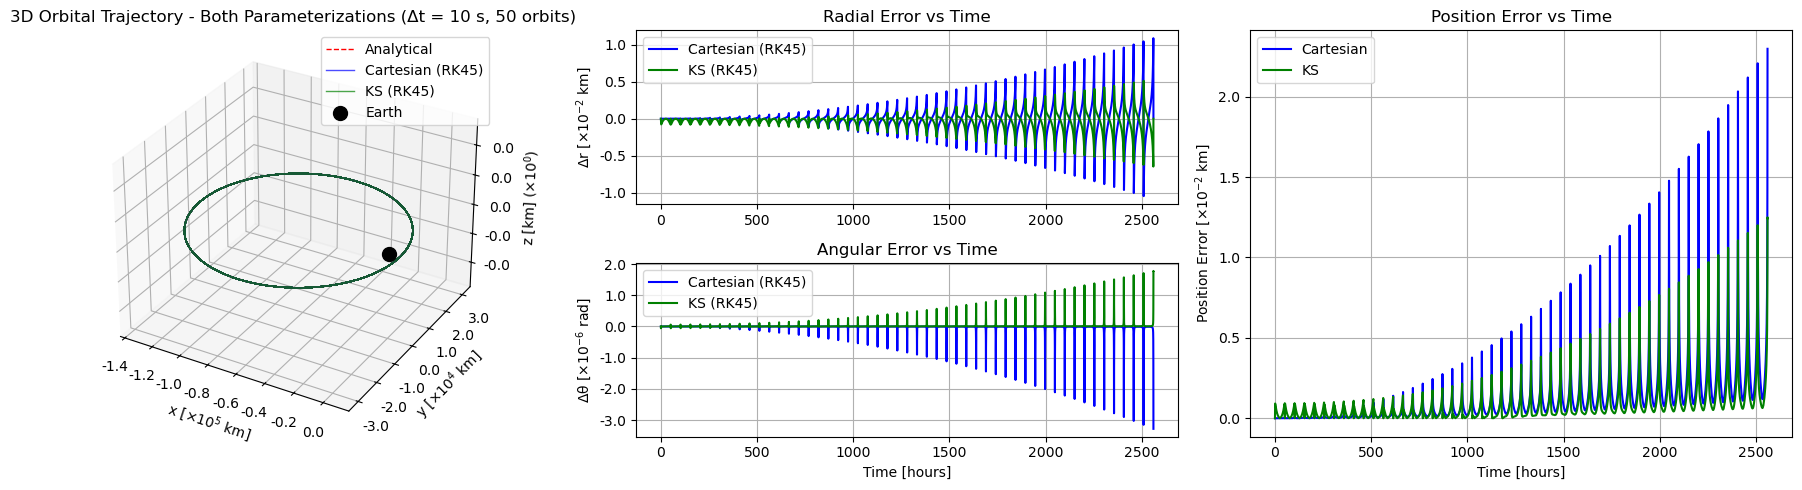

In [25]:
# Visualization mirroring the test notebook (choose Δt via dt_plot)
if dt_plot not in results_cartesian:
    raise ValueError("dt_plot must be one of dt_values")

cartesian_plot = results_cartesian[dt_plot]
ks_plot = results_ks[dt_plot]

radial_error_cartesian = cartesian_plot['dr_error']
radial_error_ks = ks_plot['dr_error']
angular_error_cartesian = cartesian_plot['dtheta_error']
angular_error_ks = ks_plot['dtheta_error']
position_error_cartesian = cartesian_plot['position_error']
position_error_ks = ks_plot['position_error']

fig = plt.figure(figsize=(18, 5))
gs = fig.add_gridspec(2, 3)

ax1 = fig.add_subplot(gs[:, 0], projection='3d')
ax1.plot(
    cartesian_plot['x_analytical'],
    cartesian_plot['y_analytical'],
    cartesian_plot['z_analytical'],
    '--',
    label='Analytical',
    color='red',
    linewidth=1,
)
ax1.plot(
    cartesian_plot['x'],
    cartesian_plot['y'],
    cartesian_plot['z'],
    label='Cartesian (RK45)',
    color='blue',
    linewidth=1,
    alpha=0.7,
)
ax1.plot(
    ks_plot['x'],
    ks_plot['y'],
    ks_plot['z'],
    label='KS (RK45)',
    color='green',
    linewidth=1,
    alpha=0.7,
)
ax1.scatter(0, 0, 0, color='black', s=100, label='Earth')
ax1.set_xlabel('x [km]')
ax1.set_ylabel('y [km]')
ax1.set_zlabel('z [km]')
ax1.set_title(
    f'3D Orbital Trajectory - Both Parameterizations (Δt = {dt_plot} s, {n_orbits} orbits)'
)
ax1.legend()

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(
    cartesian_plot['t_vals'] / 3600,
    radial_error_cartesian,
    label='Cartesian (RK45)',
    color='blue',
    linewidth=1.5,
)
ax2.plot(
    ks_plot['t_vals'] / 3600,
    radial_error_ks,
    label='KS (RK45)',
    color='green',
    linewidth=1.5,
)
ax2.set_ylabel('Δr [km]')
ax2.set_title('Radial Error vs Time')
ax2.legend()
ax2.grid(True)

ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(
    cartesian_plot['t_vals'] / 3600,
    angular_error_cartesian,
    label='Cartesian (RK45)',
    color='blue',
    linewidth=1.5,
)
ax3.plot(
    ks_plot['t_vals'] / 3600,
    angular_error_ks,
    label='KS (RK45)',
    color='green',
    linewidth=1.5,
)
ax3.set_xlabel('Time [hours]')
ax3.set_ylabel('Δθ [rad]')
ax3.set_title('Angular Error vs Time')
ax3.legend()
ax3.grid(True)

ax4 = fig.add_subplot(gs[:, 2])
ax4.plot(
    cartesian_plot['t_vals'] / 3600,
    position_error_cartesian,
    label='Cartesian',
    color='blue',
    linewidth=1.5,
)
ax4.plot(
    ks_plot['t_vals'] / 3600,
    position_error_ks,
    label='KS',
    color='green',
    linewidth=1.5,
)
ax4.set_xlabel('Time [hours]')
ax4.set_ylabel('Position Error [km]')
ax4.set_title('Position Error vs Time')
ax4.legend()
ax4.grid(True)

apply_scientific_tick_labels(
    ax1,
    'x',
    [cartesian_plot['x_analytical'], cartesian_plot['x'], ks_plot['x']],
)
apply_scientific_tick_labels(
    ax1,
    'y',
    [cartesian_plot['y_analytical'], cartesian_plot['y'], ks_plot['y']],
)
apply_scientific_tick_labels(
    ax1,
    'z',
    [cartesian_plot['z_analytical'], cartesian_plot['z'], ks_plot['z']],
)
apply_scientific_tick_labels(ax2, 'y', [radial_error_cartesian, radial_error_ks])
apply_scientific_tick_labels(ax3, 'y', [angular_error_cartesian, angular_error_ks])
apply_scientific_tick_labels(ax4, 'y', [position_error_cartesian, position_error_ks])

plt.tight_layout()
plt.show()

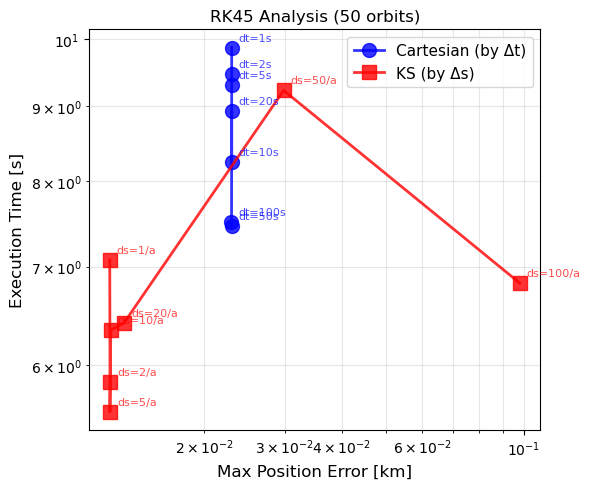

In [28]:
# Performance vs accuracy scatter (Cartesian vs KS)
max_pos_err_cart = [np.max(results_cartesian[dt]['position_error']) for dt in dt_values]
max_pos_err_ks = [np.max(results_ks[dt]['position_error']) for dt in dt_values]
time_cart = [results_cartesian[dt]['elapsed_time'] for dt in dt_values]
time_ks = [results_ks[dt]['elapsed_time'] for dt in dt_values]

fig2, ax = plt.subplots(1, 1, figsize=(6, 5))
ax.loglog(
    max_pos_err_cart,
    time_cart,
    'o-',
    linewidth=2,
    markersize=10,
    label='Cartesian (by Δt)',
    color='blue',
    alpha=0.8,
)
ax.loglog(
    max_pos_err_ks,
    time_ks,
    's-',
    linewidth=2,
    markersize=10,
    label='KS (by Δs)',
    color='red',
    alpha=0.8,
)

for i, dt in enumerate(dt_values):
    ax.annotate(
        f'dt={dt}s',
        (max_pos_err_cart[i], time_cart[i]),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=8,
        alpha=0.7,
        color='blue',
    )
    ax.annotate(
        f'ds={dt}/a',
        (max_pos_err_ks[i], time_ks[i]),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=8,
        alpha=0.7,
        color='red',
    )

ax.set_xlabel('Max Position Error [km]', fontsize=12)
ax.set_ylabel('Execution Time [s]', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, which='both')
ax.set_title(f'RK45 Analysis ({n_orbits} orbits)')

plt.tight_layout()
plt.show()